# Structural neurotransmitter fingerprinting

In this tutorial, you will explore the structural neurotransmitter fingerprinting (SNTF) functionalities of Lacuna using the CLI.

**What you'll learn**:

- Fetch the neurotransmitter PET atlas and a structural connectome
- Prepare the atlas and precompute endpoint weights
- Compute NT-weighted structural disconnectivity scores
- Filter by neurotransmitter system

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/m-petersen/lacuna/blob/main/docs/tutorials/07-structural-neurotransmitter-fingerprinting.ipynb)

## Colab

Note: Colab provides limited computational resources. While these tutorials are designed to operate within those constraints, some Lacuna functionality cannot be fully demonstrated in this environment and requires access to higher-performance computing infrastructure.

Ignore this if you run this notebook locally.

In [ ]:
# --- Conda setup for Google Colab ---
# Lacuna's structural neurotransmitter fingerprinting relies on MRtrix3.
# However, Colab does not provide MRtrix3 out of the box.
# The condacolab package provides a workaround.
# This cell installs condacolab, which will restart the kernel.
!pip install -q condacolab
import condacolab
condacolab.install()

In [ ]:
# Run this after the kernel restart. 
import sys

if 'google.colab' in sys.modules:

    import condacolab
    import subprocess
    condacolab.check()
    subprocess.run(["conda", "install", "-y", "-c", "mrtrix3", "mrtrix3"], check=True)
else:
    print("Not running in Colab — skipping condacolab setup.")

## Setup

In [ ]:
# Install Lacuna from GitHub
!pip install git+https://github.com/m-petersen/lacuna

# Install MRtrix3 via conda
!conda install -y -c mrtrix3 mrtrix3

Get the tutorial data.

In [2]:
# Get tutorial data
!lacuna tutorial /tmp/tutorial_bids --force


Setting up tutorial data at: /tmp/tutorial_bids
✓ Tutorial data copied to: /tmp/tutorial_bids

The tutorial dataset includes:
  - 3 synthetic subjects (sub-01, sub-02, sub-03)
  - Binary lesion masks in MNI152NLin6Asym space
  - BIDS-style structure


Check whether MRtrix3 is properly installed as it is required for the analysis.

In [1]:
!mrinfo --version

== mrinfo 3.0.8 ==
64 bit release version, built Oct 21 2025, using Eigen 3.4.0
Author(s): J-Donald Tournier (jdtournier@gmail.com) and Robert E. Smith (robert.smith@florey.edu.au)
Copyright (c) 2008-2025 the MRtrix3 contributors.

This Source Code Form is subject to the terms of the Mozilla Public
License, v. 2.0. If a copy of the MPL was not distributed with this
file, You can obtain one at http://mozilla.org/MPL/2.0/.

Covered Software is provided under this License on an "as is"
basis, without warranty of any kind, either expressed, implied, or
statutory, including, without limitation, warranties that the
Covered Software is free of defects, merchantable, fit for a
particular purpose or non-infringing.
See the Mozilla Public License v. 2.0 for more details.

For more details, see http://www.mrtrix.org/.



## Fetch data

SNTF requires two data sources:

1. **Neurotransmitter PET atlas** — curated representative PET receptor / transporter density maps from [NiSpace-data](https://github.com/LeonDLotter/NiSpace-data), pinned to a specific commit and verified by SHA-256.
2. **Structural connectome** — A normative tractogram of white matter fiber bundles (e.g., HCP1065).

In [5]:
# Fetch NT atlas
!lacuna fetch ntatlas \
    --output-dir /tmp/ntatlas_data \
    --force

Fetching neurotransmitter PET maps...
  Source: https://github.com/LeonDLotter/NiSpace-data
  Commit: a772c410f76dbbd022a3f5239e40176ff6f930c7


✓ Neurotransmitter atlas fetch complete!
  Files: 22
  Duration: 8.7s
  Output: /tmp/ntatlas_data


In [6]:
# Fetch structural connectome
!lacuna fetch hcp1065 \
    --output-dir /tmp/hcp1065_data

Fetching HCP1065 structural tractogram...
  Output: /tmp/hcp1065_data
  Keep original: True

hcp1065_avg_tracts_trk.zip: 100%|████████████| 588M/588M [00:15<00:00, 37.2MB/s]
Found 77 tract files (10 excluded)
Loading and merging streamlines...
Merging tracts: 100%|███████████████████████████| 77/77 [00:16<00:00,  4.53it/s]
Processed 77 files, 479804 total streamlines
Saving merged tractogram to /tmp/hcp1065_data/hcp1065.tck...
Merge complete: /tmp/hcp1065_data/hcp1065.tck

✓ HCP1065 fetch complete!
  Files: 2
  Duration: 41.8s
  Output: /tmp/hcp1065_data


## Precompute endpoint weights

`lacuna prepare sntf` precomputes per-streamline endpoint NT weights from the fetched atlas + tractogram. This step is slow because it samples the tractogram with MRtrix, but only runs once per (atlas, tractogram) pair.

In [8]:
!ls /tmp/hcp1065_data/

hcp1065_avg_tracts_trk.zip  hcp1065.tck  hcp1065_tracts


In [10]:
# Step 2: Precompute endpoint weights for the tractogram
!lacuna prepare sntf \
    --atlas-cache-dir /tmp/ntatlas_data \
    --connectome-path /tmp/hcp1065_data/hcp1065.tck \
    --cache-dir /tmp/sntf_cache

2026-04-29 16:39:22 - lacuna.cli.prepare - INFO - Loaded NT atlas with 22 targets
2026-04-29 16:39:22 - lacuna.cli.prepare - INFO - Computing endpoint NT weights for tractogram...
   Executing: tckresample /tmp/hcp1065_data/hcp1065.tck /tmp/sntf_cache/endpoints.tck -endpoints
tckresample: [done] resampling streamlines (count: 479804, skipped: 0)
2026-04-29 16:39:33 - lacuna.cli.prepare - INFO - Saved endpoint weights: shape (22, 479804)
Endpoint weights saved to /tmp/sntf_cache


## Analysis

Structural neurotransmitter fingerprinting combines structural disconnection with neurotransmitter information. It:

1. Filters the normative tractogram by the lesion mask to identify disconnected streamlines
2. Looks up NT atlas values at the endpoints of those disconnected streamlines
3. Scores each neurotransmitter target based on the endpoint values

A high score for a given target indicates that the lesion disconnects pathways whose endpoints are rich in that neurotransmitter.

This procedure follows the implementation by [Koch, Frey et al](https://academic.oup.com/brain/article-lookup/doi/10.1093/brain/awaf185).

Run the analysis.

In [13]:
!lacuna run sntf \
    /tmp/tutorial_bids/ \
    /tmp/outputs_sntf/ \
    --connectome-path /tmp/hcp1065_data/hcp1065.tck \
    --participant-label 01 \
    --mask-space MNI152NLin6Asym \
    --atlas-cache-dir /tmp/ntatlas_data

List the outputs.

In [14]:
!ls /tmp/outputs_sntf/sub-01/ses-01/anat/

sub-01_ses-01_label-acuteinfarct_method-sntf_atlas-neurotransmitter_desc-static_profilestats.json
sub-01_ses-01_label-acuteinfarct_method-sntf_atlas-neurotransmitter_desc-static_profilestats.tsv


## Visualize the fingerprint

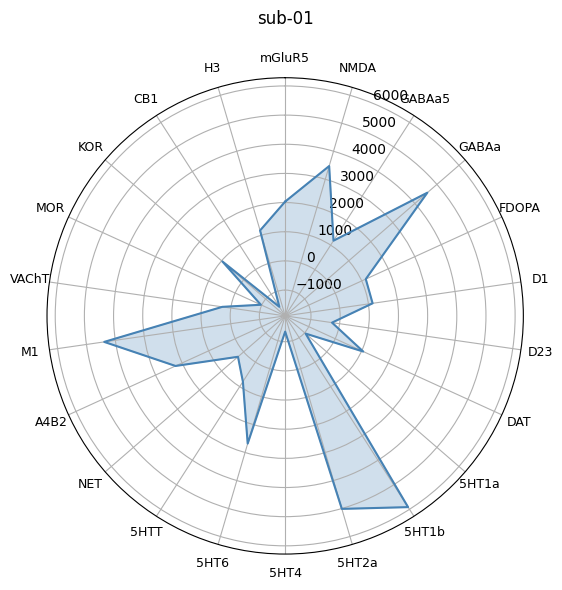

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

tsv = next(Path("/tmp/outputs_sntf/sub-01/ses-01/anat").glob("*sntf*profilestats.tsv"))
df = pd.read_csv(tsv, sep="\t")

targets = df["target"].tolist()
values = df["value"].to_numpy()
angles = np.linspace(0, 2 * np.pi, len(targets), endpoint=False)

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection="polar"))
ax.plot(np.append(angles, angles[0]), np.append(values, values[0]),
        color="steelblue", linewidth=1.5)
ax.fill(np.append(angles, angles[0]), np.append(values, values[0]),
        color="steelblue", alpha=0.25)
ax.set_xticks(angles)
ax.set_xticklabels(targets, fontsize=9)
ax.set_title("sub-01", pad=20)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
plt.tight_layout()
plt.show()


## Disconnected endpoints alongside the top NT target

Filter the tractogram to streamlines that intersect the lesion, take their endpoints, and overlay the endpoint density on top of the highest-scoring NT map. This shows *where* the disconnected white-matter bundles terminate — and how that termination footprint aligns with the NT receptor that scored highest.

In [ ]:
import nibabel as nib
import numpy as np
import subprocess
from pathlib import Path
from nilearn import plotting

# ---- 1. mrtrix: lesion-intersecting streamlines + their endpoints --------
work = Path("/tmp/sntf_viz")
work.mkdir(exist_ok=True)
lesion_path = next(Path("/tmp/tutorial_bids/sub-01/ses-01/anat").glob("*mask*.nii.gz"))
filtered_tck = work / "filtered.tck"
endpoints_tck = work / "endpoints.tck"
subprocess.run(
    ["tckedit", "/tmp/hcp1065_data/hcp1065.tck", str(filtered_tck),
     "-include", str(lesion_path), "-force"],
    check=True,
)
subprocess.run(
    ["tckresample", str(filtered_tck), str(endpoints_tck), "-endpoints", "-force"],
    check=True,
)

# ---- 2. Endpoint density on the atlas grid -------------------------------
top_target = df["target"].iloc[df["value"].argmax()]
nt_map = nib.load(f"/tmp/ntatlas_data/maps/{top_target}.nii.gz")

inv_aff = np.linalg.inv(nt_map.affine)
density = np.zeros(nt_map.shape, dtype=np.int32)
for sl in nib.streamlines.load(str(endpoints_tck)).streamlines:
    for pt in (sl[0], sl[-1]):
        v = (inv_aff[:3, :3] @ pt + inv_aff[:3, 3]).astype(int)
        if (0 <= v).all() and (v < np.array(nt_map.shape)).all():
            density[v[0], v[1], v[2]] += 1
density_img = nib.Nifti1Image(density.astype(np.float32), nt_map.affine)

# ---- 3. Plot: NT map + endpoint density + lesion contour -----------------
lesion_centroid = nib.affines.apply_affine(
    nib.load(lesion_path).affine,
    np.argwhere(nib.load(lesion_path).get_fdata() > 0).mean(axis=0),
)
display = plotting.plot_stat_map(
    nt_map, threshold=1.0, display_mode="ortho", cut_coords=tuple(lesion_centroid),
    title=f"sub-01: {top_target} (top score) + disconnected endpoints",
    colorbar=True,
)
display.add_overlay(density_img, cmap="autumn", alpha=0.7)
display.add_contours(str(lesion_path), levels=[0.5], colors="lime", linewidths=2)
plotting.show()
